<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
The first task involves building a classification model to predict whether a retail transaction
is fraudulent. The dataset contains transaction information, and careful feature engineering is
required to avoid data leakage. All features must be computed using only information available
before the target event.
</div>

<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Check / Install / Import Dependencies</h1>

In [68]:
import sys
import subprocess
import importlib

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "scikit-learn": "sklearn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "openpyxl": "openpyxl"
}

def install_if_missing(pip_name, import_name):
    try:
        importlib.import_module(import_name)
        print(f"✅ {pip_name}")
    except ImportError:
        print(f"📦 Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

for pip_name, import_name in required_packages.items():
    install_if_missing(pip_name, import_name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Minimal environment is ready.")


✅ pandas
✅ numpy
✅ scikit-learn
✅ matplotlib
✅ seaborn
✅ openpyxl
✅ Minimal environment is ready.



<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Load Data + Initial EDA</h1>

In [69]:
# File paths
train_path = "data/task1_dataset/train.xlsx"
cv_path = "data/task1_dataset/student_test.xlsx"

# Load data
train_df = pd.read_excel(train_path)
cv_df = pd.read_excel(cv_path)


print("Data loaded successfully.\n")


Data loaded successfully.



<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Info + Missing Values + Duplicates</h1>

In [70]:
print("="*80)
print("TRAIN INFO")
print("="*80)
display(train_df.info())

print("\n" + "="*80)
print("TEST INFO")
print("="*80)
display(cv_df.info())

# Missing values summary
train_missing = pd.DataFrame({
    "missing_count": train_df.isnull().sum(),
    "missing_percent": (train_df.isnull().sum() / len(train_df)) * 100
}).sort_values(by="missing_percent", ascending=False)

test_missing = pd.DataFrame({
    "missing_count": cv_df.isnull().sum(),
    "missing_percent": (cv_df.isnull().sum() / len(cv_df)) * 100
}).sort_values(by="missing_percent", ascending=False)

print("\n" + "="*80)
print("TRAIN MISSING VALUES")
print("="*80)
display(train_missing[train_missing["missing_count"] > 0])

print("\n" + "="*80)
print("TEST MISSING VALUES")
print("="*80)
display(test_missing[test_missing["missing_count"] > 0])

# Duplicate rows
print("\n" + "="*80)
print("DUPLICATE CHECK")
print("="*80)
print(f"Train duplicate rows: {train_df.duplicated().sum()}")
print(f"Test duplicate rows : {cv_df.duplicated().sum()}")


TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   transaction_id                    80000 non-null  object
 1   customer_id                       80000 non-null  object
 2   transaction_timestamp             80000 non-null  object
 3   transaction_amount                78164 non-null  object
 4   payment_method                    79190 non-null  object
 5   device_type                       79174 non-null  object
 6   location                          79184 non-null  object
 7   merchant_category                 79193 non-null  object
 8   is_international                  80000 non-null  object
 9   transaction_frequency_24h         78608 non-null  object
 10  avg_transaction_amount_7d         78126 non-null  object
 11  failed_transaction_count_24h      78575 non-null  object
 12  account

None


TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   id                                20000 non-null  int64 
 1   transaction_id                    20000 non-null  object
 2   customer_id                       20000 non-null  object
 3   transaction_timestamp             20000 non-null  object
 4   transaction_amount                19525 non-null  object
 5   payment_method                    19810 non-null  object
 6   device_type                       19826 non-null  object
 7   location                          19816 non-null  object
 8   merchant_category                 19807 non-null  object
 9   is_international                  20000 non-null  object
 10  transaction_frequency_24h         19641 non-null  object
 11  avg_transaction_amount_7d         19548 non-null  object
 12  failed_

None


TRAIN MISSING VALUES


,missing_count,missing_percent
avg_transaction_amount_7d,1874,2.34250
transaction_amount,1836,2.29500
failed_transaction_count_24h,1425,1.78125
account_age_days,1414,1.76750
transaction_frequency_24h,1392,1.74000
device_type,826,1.03250
location,816,1.02000
payment_method,810,1.01250
merchant_category,807,1.00875



TEST MISSING VALUES


,missing_count,missing_percent
transaction_amount,475,2.375
avg_transaction_amount_7d,452,2.260
transaction_frequency_24h,359,1.795
account_age_days,352,1.760
failed_transaction_count_24h,333,1.665
merchant_category,193,0.965
payment_method,190,0.950
location,184,0.920
device_type,174,0.870



DUPLICATE CHECK
Train duplicate rows: 0
Test duplicate rows : 0


<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Target Distribution</h1>

TARGET DISTRIBUTION


,count,percent
label,,
0,41947,52.43375
1,38053,47.56625


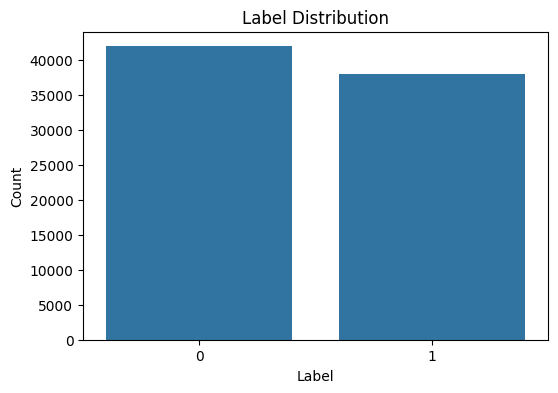

In [71]:
print("="*80)
print("TARGET DISTRIBUTION")
print("="*80)

label_counts = train_df["label"].value_counts(dropna=False).sort_index()
label_percent = train_df["label"].value_counts(normalize=True, dropna=False).sort_index() * 100

target_summary = pd.DataFrame({
    "count": label_counts,
    "percent": label_percent
})

display(target_summary)

plt.figure(figsize=(6,4))
sns.countplot(x="label", data=train_df)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Quick Numeric/Categorical Overview</h1>

In [72]:
print("="*80)
print("NUMERIC COLUMNS")
print("="*80)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)

print("\n" + "="*80)
print("CATEGORICAL COLUMNS")
print("="*80)
categorical_cols = train_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print(categorical_cols)

print("\n" + "="*80)
print("NUMERIC SUMMARY")
print("="*80)
display(train_df.describe(include=[np.number]).T)

print("\n" + "="*80)
print("CATEGORICAL SUMMARY")
print("="*80)
display(train_df.describe(include=["object", "category", "bool"]).T)


NUMERIC COLUMNS
['label']

CATEGORICAL COLUMNS
['transaction_id', 'customer_id', 'transaction_timestamp', 'transaction_amount', 'payment_method', 'device_type', 'location', 'merchant_category', 'is_international', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days', 'unusual_amount_flag', 'multiple_transactions_short_time', 'high_risk_device_flag']

NUMERIC SUMMARY


,count,mean,std,min,25%,50%,75%,max
label,80000.0,0.475662,0.49941,0.0,0.0,0.0,1.0,1.0



CATEGORICAL SUMMARY


,count,unique,top,freq
transaction_id,80000,80000,T0024477,1
customer_id,80000,27937,C00353,12
transaction_timestamp,80000,80000,2026-02-16 19:56:24.183744,1
transaction_amount,78164.0,29733.0,-99.99,322.0
payment_method,79190,37,Debit Card,14710
device_type,79174,24,Mobile,24497
location,79184,38,Canada,12268
merchant_category,79193,41,Fashion,12340
is_international,80000,10,false,8115
transaction_frequency_24h,78608,184,3,5612


<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Unique Values for Low-Cardinality Columns</h1>

In [73]:
print("="*80)
print("UNIQUE VALUES OF CATEGORICAL / LOW-CARDINALITY COLUMNS")
print("="*80)

for col in train_df.columns:
    n_unique = train_df[col].nunique(dropna=False)
    if n_unique <= 20:
        print(f"\nColumn: {col}")
        print(f"Unique values ({n_unique}):")
        print(train_df[col].value_counts(dropna=False))


UNIQUE VALUES OF CATEGORICAL / LOW-CARDINALITY COLUMNS

Column: is_international
Unique values (10):
is_international
false    8115
FALSE    8044
N        8027
0        8025
1        8020
Y        8016
TRUE     8013
true     7936
no       7917
yes      7887
Name: count, dtype: int64

Column: unusual_amount_flag
Unique values (10):
unusual_amount_flag
no       12499
FALSE    12382
0        12335
N        12260
false    12208
Y         3719
yes       3698
true      3666
1         3659
TRUE      3574
Name: count, dtype: int64

Column: multiple_transactions_short_time
Unique values (10):
multiple_transactions_short_time
no       9273
N        9214
FALSE    9179
0        9142
false    9075
TRUE     6936
1        6870
yes      6861
Y        6743
true     6707
Name: count, dtype: int64

Column: high_risk_device_flag
Unique values (10):
high_risk_device_flag
false    14609
N        14449
FALSE    14435
no       14307
0        14183
true      1675
yes       1606
Y         1586
1         1582
TR

<h1 style="margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Cleaning</h1>

In [74]:
import numpy as np
import pandas as pd

# ----------------------------
# Constants
# ----------------------------
BOOL_MAP = {
    "true": 1, "false": 0, "1": 1, "0": 0,
    "yes": 1, "no": 0, "y": 1, "n": 0, "t": 1, "f": 0
}

sentinel_map = {
    "transaction_amount": -99.99,
    "account_age_days": -30,
    "transaction_frequency_24h": -3,
    "avg_transaction_amount_7d": -1,
    "failed_transaction_count_24h": -2,
}

numeric_cols = [
    "transaction_amount",
    "transaction_frequency_24h",
    "avg_transaction_amount_7d",
    "failed_transaction_count_24h",
    "account_age_days"
]

bool_like_cols = [
    "is_international",
    "unusual_amount_flag",
    "multiple_transactions_short_time",
    "high_risk_device_flag"
]

categorical_cols = [
    "payment_method",
    "device_type",
    "location",
    "merchant_category"
]

drop_noise = ["transaction_id", "customer_id"]


# ----------------------------
# Helpers
# ----------------------------
def to_bool01(x):
    if pd.isna(x):
        return np.nan
    return BOOL_MAP.get(str(x).strip().lower(), np.nan)


def fit_target_encoder(X_tr, y_tr, col, smoothing=30):
    df = pd.DataFrame({col: X_tr[col], "y": y_tr})
    global_mean = df["y"].mean()

    stats = df.groupby(col)["y"].agg(["mean", "count"])

    stats["te"] = (
        stats["count"] * stats["mean"] +
        smoothing * global_mean
    ) / (stats["count"] + smoothing)

    return stats["te"].to_dict(), float(global_mean)


def apply_target_encoder(X, col, mapping, global_mean, out_col):
    X[out_col] = X[col].map(mapping).fillna(global_mean).astype(float)
    return X


# ----------------------------
# Main preprocessing
# ----------------------------
def preprocess_fit_transform(X_train, X_valid, y_train=None):

    X_tr = X_train.copy()
    X_va = X_valid.copy()

    # ============================================
    # 1. DATETIME FEATURES (much richer)
    # ============================================
    for df in (X_tr, X_va):
        df["transaction_timestamp"] = pd.to_datetime(
            df["transaction_timestamp"],
            errors="coerce"
        )

        df["tx_second"] = df["transaction_timestamp"].dt.second.astype(float)
        df["tx_dayofweek"] = df["transaction_timestamp"].dt.dayofweek
        df["tx_day"] = df["transaction_timestamp"].dt.day
        df["tx_is_weekend"] = (df["tx_dayofweek"] >= 5).astype(float)

        df.drop(columns=["transaction_timestamp"], inplace=True)

    # ============================================
    # 2. Drop IDs
    # ============================================
    for df in (X_tr, X_va):
        df.drop(columns=[c for c in drop_noise if c in df.columns],
                inplace=True)

    # ============================================
    # 3. Boolean normalize
    # ============================================
    for col in bool_like_cols:
        for df in (X_tr, X_va):
            if col in df.columns:
                df[col] = df[col].map(to_bool01).astype(float)

    # ============================================
    # 4. Numeric + sentinel
    # ============================================
    for col in numeric_cols:
        for df in (X_tr, X_va):
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
                df.loc[df[col] == sentinel_map[col], col] = np.nan

                # missing indicator
                df[f"{col}_missing"] = df[col].isna().astype(float)

    # ============================================
    # 5. Clean categoricals
    # ============================================
    for col in categorical_cols:
        for df in (X_tr, X_va):
            if col in df.columns:
                df[col] = (
                    df[col]
                    .astype(str)
                    .str.strip()
                    .str.lower()
                    .replace(["nan", "missing", "null", "none"], np.nan)
                )

    # ============================================
    # 6. Imputation
    # ============================================
    num_features = [c for c in X_tr.columns if X_tr[c].dtype != "object"]

    med = X_tr[num_features].median()

    X_tr[num_features] = X_tr[num_features].fillna(med)
    X_va[num_features] = X_va[num_features].fillna(med)

    for col in categorical_cols:
        if col in X_tr.columns:
            X_tr[col] = X_tr[col].fillna("missing_cat")
            X_va[col] = X_va[col].fillna("missing_cat")

    # ============================================
    # 7. Better Target Encoding
    # ============================================
    te_cols = ["location", "merchant_category"]

    if y_train is not None:
        for col in te_cols:
            if col in X_tr.columns:
                mapping, gm = fit_target_encoder(
                    X_tr, y_train, col, smoothing=40
                )

                X_tr = apply_target_encoder(
                    X_tr, col, mapping, gm, f"{col}_te"
                )
                X_va = apply_target_encoder(
                    X_va, col, mapping, gm, f"{col}_te"
                )

    # ============================================
    # 8. DEEP FEATURE ENGINEERING
    # ============================================
    for df in (X_tr, X_va):

        eps = 1



        # ------------------------------------------------
        # 1. second × location inconsistency
        # ------------------------------------------------
        df["sec_location"] = (
            df["tx_second"].astype(str) + "_" +
            df["location"].astype(str)
        )

        # ------------------------------------------------
        # 2. second × merchant pattern
        # ------------------------------------------------
        df["sec_merchant"] = (
            df["tx_second"].astype(str) + "_" +
            df["merchant_category"].astype(str)
        )

        # ------------------------------------------------
        # 3. second × payment method
        # ------------------------------------------------
        df["sec_payment"] = (
            df["tx_second"].astype(str) + "_" +
            df["payment_method"].astype(str)
        )

        # ------------------------------------------------
        # 4. geo-temporal impossible behavior
        # ------------------------------------------------
        df["instant_geo_jump"] = (
            (df["is_international"] == 1) &
            (df["multiple_transactions_short_time"] == 1)
        ).astype(float)

        # ------------------------------------------------
        # 5. suspicious repeated second
        # ------------------------------------------------
        df["same_second_burst"] = (
            (df["transaction_frequency_24h"] > 8) &
            (df["tx_second"] < 5)
        ).astype(float)

        # ------------------------------------------------
        # 6. high-risk synchronized attack
        # ------------------------------------------------
        df["coordinated_attack"] = (
            df["high_risk_device_flag"] *
            df["multiple_transactions_short_time"] *
            df["is_international"]
        )

        # ------------------------------------------------
        # 7. location-time collision score
        # ------------------------------------------------
        df["location_second_risk"] = (
            df["location_te"] *
            (df["tx_second"] / 60.0)
        )

        # ------------------------------------------------
        # 8. merchant-second anomaly
        # ------------------------------------------------
        df["merchant_second_risk"] = (
            df["merchant_category_te"] *
            (1 + (df["tx_second"] % 10))
        )

        # core ratios
        df["amount_to_avg_ratio"] = (
            df["transaction_amount"] /
            (df["avg_transaction_amount_7d"] + eps)
        )

        df["amount_delta"] = (
            df["transaction_amount"] -
            df["avg_transaction_amount_7d"]
        )

        df["amount_zproxy"] = (
            df["amount_delta"] /
            (df["avg_transaction_amount_7d"] + eps)
        )

        df["failure_rate"] = (
            df["failed_transaction_count_24h"] /
            (df["transaction_frequency_24h"] + eps)
        )

        df["velocity_per_day_age"] = (
            df["transaction_frequency_24h"] /
            (df["account_age_days"] + eps)
        )

        # account risk
        df["new_account"] = (df["account_age_days"] < 30).astype(float)
        df["very_new_account"] = (df["account_age_days"] < 7).astype(float)

        # fraud signatures
        df["intl_unusual"] = (
            df["is_international"] *
            df["unusual_amount_flag"]
        )

        df["device_burst"] = (
            df["high_risk_device_flag"] *
            df["multiple_transactions_short_time"]
        )

        df["triple_risk"] = (
            df["intl_unusual"] *
            df["device_burst"]
        )

        # spike severity
        df["spike_3x"] = (
            df["transaction_amount"] >
            3 * df["avg_transaction_amount_7d"]
        ).astype(float)

        df["spike_5x"] = (
            df["transaction_amount"] >
            5 * df["avg_transaction_amount_7d"]
        ).astype(float)

        # combined anomaly score
        df["risk_score"] = (
            2*df["unusual_amount_flag"] +
            2*df["high_risk_device_flag"] +
            1.5*df["is_international"] +
            1.5*df["multiple_transactions_short_time"] +
            3*df["failure_rate"]
        )

    # ============================================
    # 9. Log transforms
    # ============================================
    for col in [
        "transaction_amount",
        "avg_transaction_amount_7d",
        "transaction_frequency_24h"
    ]:
        for df in (X_tr, X_va):
            df[col] = np.log1p(df[col].clip(lower=0))

    cross_te_cols = [
    "sec_location",
    "sec_merchant",
    "sec_payment"
    ]

    for col in cross_te_cols:
        if y_train is not None:
            mapping, gm = fit_target_encoder(
                X_tr, y_train, col, smoothing=50
            )

            X_tr = apply_target_encoder(
                X_tr, col, mapping, gm, f"{col}_te"
            )

            X_va = apply_target_encoder(
                X_va, col, mapping, gm, f"{col}_te"
            )
    X_tr.drop(columns=cross_te_cols, errors="ignore", inplace=True)
    X_va.drop(columns=cross_te_cols, errors="ignore", inplace=True)
    # ============================================
    # 10. One-hot low-card cats
    # ============================================
    cat_features = ["payment_method", "device_type"]

    for col in cat_features:
        if col in X_tr.columns:
            freq = X_tr[col].value_counts(normalize=True)
            rare = freq[freq < 0.01].index

            X_tr[col] = X_tr[col].replace(rare, "other")
            X_va[col] = X_va[col].replace(rare, "other")

    X_tr = pd.get_dummies(
        X_tr,
        columns=cat_features,
        drop_first=True
    )

    X_va = pd.get_dummies(
        X_va,
        columns=cat_features,
        drop_first=True
    )

    X_va = X_va.reindex(columns=X_tr.columns, fill_value=0)

    # drop original TE cols
    X_tr.drop(columns=["location", "merchant_category"],
              errors="ignore", inplace=True)

    X_va.drop(columns=["location", "merchant_category"],
              errors="ignore", inplace=True)

    return X_tr.astype(float), X_va.astype(float)

In [75]:
X_all_raw = train_df.drop(columns=["label"]).copy()
y_all = train_df["label"].copy()

In [76]:
import xgboost as xgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, cohen_kappa_score
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_pred = np.zeros(len(X_all_raw), dtype=float)
auc_scores = []

# ---- CV loop: fill oof_pred ----
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_all_raw, y_all), 1):
    X_tr_raw = X_all_raw.iloc[tr_idx].copy()
    X_va_raw = X_all_raw.iloc[va_idx].copy()
    y_tr = y_all.iloc[tr_idx].copy()
    y_va = y_all.iloc[va_idx].copy()

    X_tr, X_va = preprocess_fit_transform(X_tr_raw, X_va_raw, y_train=y_tr)

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=1,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        reg_alpha=0.0,
        eval_metric="logloss",
        random_state=42,
        tree_method="hist",
        n_jobs=-1,
    )

    model.fit(X_tr, y_tr)

    va_pred = model.predict_proba(X_va)[:, 1]
    oof_pred[va_idx] = va_pred

    fold_auc = roc_auc_score(y_va, va_pred)
    auc_scores.append(fold_auc)
    print(f"Fold {fold}: AUC = {fold_auc:.5f}")

print(f"Mean AUC: {np.mean(auc_scores):.5f} ± {np.std(auc_scores):.5f}")

# ---- Now compute global OOF metrics (correct place) ----
y_true = y_all.values
proba = oof_pred

print("OOF proba stats:", proba.min(), proba.max(), proba.mean())

auc_oof = roc_auc_score(y_true, proba)
print(f"ROC-AUC (OOF): {auc_oof:.5f}")

def metrics_at_threshold(thr: float):
    y_pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)   # sensitivity
    f1 = f1_score(y_true, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    return thr, acc, prec, rec, spec, f1, mcc, kappa, (tn, fp, fn, tp)

# metrics @ 0.5
thr = 0.5
thr, acc, prec, rec, spec, f1, mcc, kappa, cm = metrics_at_threshold(thr)
tn, fp, fn, tp = cm
print(f"\nThreshold={thr}")
print(f"Accuracy={acc:.5f} Precision={prec:.5f} Recall={rec:.5f} Specificity={spec:.5f}")
print(f"F1={f1:.5f} MCC={mcc:.5f} Kappa={kappa:.5f}")
print("CM [[TN,FP],[FN,TP]] =", [[tn, fp], [fn, tp]])

# best threshold for F1
best = None
for thr in np.linspace(0.01, 0.99, 99):
    out = metrics_at_threshold(thr)
    if best is None or out[5] > best[5]:  # compare F1
        best = out

thr, acc, prec, rec, spec, f1, mcc, kappa, cm = best
tn, fp, fn, tp = cm
print(f"\nBest-F1 threshold={thr:.2f}  F1={f1:.5f}  P={prec:.5f}  R={rec:.5f}  Spec={spec:.5f}")
print("CM [[TN,FP],[FN,TP]] =", [[tn, fp], [fn, tp]])


Fold 1: AUC = 0.91022
Fold 2: AUC = 0.91287
Fold 3: AUC = 0.91311
Fold 4: AUC = 0.91354
Fold 5: AUC = 0.90909
Mean AUC: 0.91176 ± 0.00177
OOF proba stats: 3.4620912629179657e-05 0.9999908208847046 0.475837777179723
ROC-AUC (OOF): 0.91177

Threshold=0.5
Accuracy=0.79090 Precision=0.77766 Recall=0.78477 Specificity=0.79646
F1=0.78120 MCC=0.58101 Kappa=0.58098
CM [[TN,FP],[FN,TP]] = [[np.int64(33409), np.int64(8538)], [np.int64(8190), np.int64(29863)]]

Best-F1 threshold=0.29  F1=0.81787  P=0.69400  R=0.99556  Spec=0.60178
CM [[TN,FP],[FN,TP]] = [[np.int64(25243), np.int64(16704)], [np.int64(169), np.int64(37884)]]


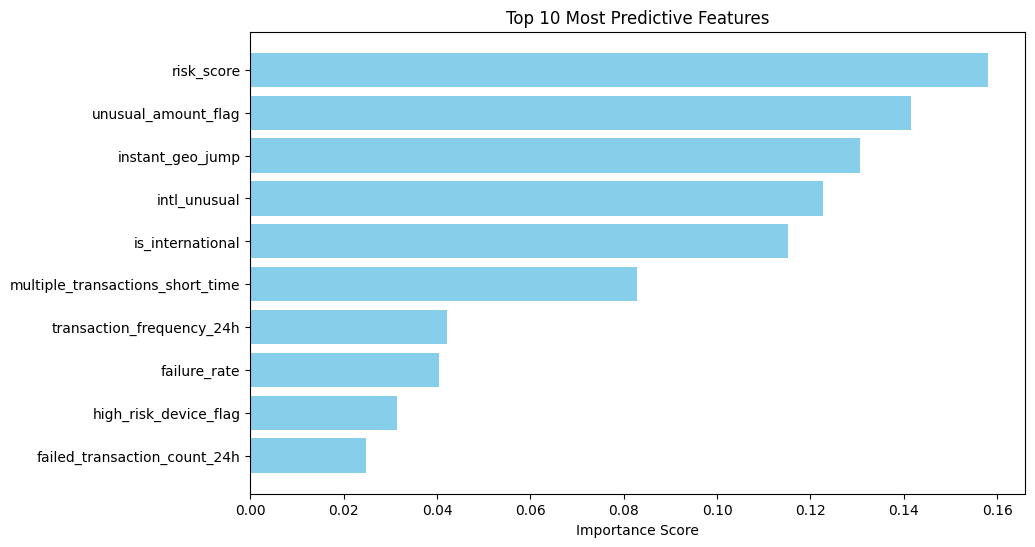

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

importances = model.feature_importances_
feature_names = X_tr.columns

feature_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['feature'].head(10), feature_imp_df['importance'].head(10), color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Most Predictive Features')
plt.gca().invert_yaxis()
plt.show()

In [78]:
import numpy as np
import pandas as pd
import xgboost as xgb


TARGET = "label"
IDCOL  = "id"

X_train_raw = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET].astype(int)

X_test_raw = cv_df.copy()

# ---- preprocess (MUST match your existing functions) ----
# This assumes you already have these implemented exactly as in CV:
# - preprocess_fit_transform(train_raw, valid_raw, y_train=...)
# If you also have a "fit_on_train_transform_test" helper, use it.
X_train, X_test = preprocess_fit_transform(X_train_raw, X_test_raw, y_train=y_train)

# ---- model (best params) ----
model = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=1,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=2.0,
    reg_alpha=0.0,
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
)

model.fit(X_train, y_train)

# ---- predict ----
test_proba = model.predict_proba(X_test)[:, 1]

THR = 0.29
test_pred = (test_proba >= THR).astype(int)

# ---- submission ----
sub = pd.DataFrame({
    IDCOL: cv_df[IDCOL].values,
    TARGET: test_pred
})

sub_path = "data/task1_dataset/submission.csv"
sub.to_csv(sub_path, index=False)

# optional: save probabilities for sanity-checking
proba_path = "data/task1_dataset/submission_with_proba.csv"
pd.DataFrame({IDCOL: cv_df[IDCOL].values, "proba": test_proba, TARGET: test_pred}).to_csv(proba_path, index=False)

print("Saved:", sub_path)
print("Also saved:", proba_path)
print("Pred positive rate:", test_pred.mean())
print("Proba stats:", float(test_proba.min()), float(test_proba.max()), float(test_proba.mean()))


Saved: data/task1_dataset/submission.csv
Also saved: data/task1_dataset/submission_with_proba.csv
Pred positive rate: 0.68535
Proba stats: 3.259873847127892e-05 0.9999935626983643 0.4778505265712738
